# ALUR PEMBUATAN MODEL MACHINE LEARNING BERBASIS TEKS
## KitchenGuard CSM — Automated Quality Control & Waste Prevention
**Capstone Project ITB STIKOM Bali x PT Central Saga Mandala**

Notebook ini mengimplementasikan alur lengkap 10 langkah pembuatan model Machine Learning berbasis teks:
1. **Pencarian & Pengumpulan Dataset:** Pengumpulan teks catatan log operasional limbah dapur berbahasa Indonesia.
2. **Pelabelan Data:** Pelabelan target kategori limbah (`SPOILED`, `EXPIRED`, `PREP_WASTE`, `OVERCOOKED`, `CONTAMINATED`, `SURPLUS`).
3. **Pembersihan & Praproses Teks:** Menghapus duplikasi, case folding, tokenisasi, stopword removal, dan stemming Sastrawi.
4. **Analisis dan Pembagian Data:** EDA distribusi data dan stratified split (Train 70%, Val 15%, Test 15%).
5. **Representasi Teks:** TF-IDF Vectorizer (Unigram + Bigram).
6. **Pemilihan Algoritma:** Komparasi Naive Bayes, Linear SVM, Logistic Regression, dan Random Forest.
7. **Pelatihan Model:** Fitting data latih dan penyesuaian parameter.
8. **Evaluasi Model:** Pengukuran Accuracy, Precision, Recall, Macro F1, Confusion Matrix, dan Decision Gate.
9. **Simpan Model:** Serialisasi model dan vectorizer ke direktori `models/`.
10. **Implementasi & Prediksi Teks Baru:** Inferensi teks baru dengan confidence gate KitchenGuard.

In [2]:
# Import pustaka yang dibutuhkan
import os
import sys
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

# Tambahkan src ke path
sys.path.append(os.path.abspath(os.path.join("..", "src")))
from preprocess import clean_and_preprocess_dataframe, preprocess_text

# Style visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.sans-serif': 'Arial', 'font.size': 10})
print("Pustaka berhasil diimpor!")

Pustaka berhasil diimpor!


---
## Langkah 1: Pencarian & Pengumpulan Dataset & Langkah 2: Pelabelan Data

Tujuan bisnis model adalah mengklasifikasikan catatan insiden atau deskripsi limbah dapur yang dimasukkan oleh staf ke dalam sistem KitchenGuard menjadi salah satu dari 6 kategori operasional:
1. `SPOILED` (Bahan busuk, berlendir, berjamur)
2. `EXPIRED` (Lewat masa simpan atau tanggal kadaluarsa)
3. `PREP_WASTE` (Sisa kupasan, potongan lemak/tulang persiapan memasak)
4. `OVERCOOKED` (Salah pengolahan, gosong, hangus, over-seasoned)
5. `CONTAMINATED` (Jatuh ke lantai kotor, terkena cairan kimia/alergen)
6. `SURPLUS` (Kelebihan masak, sisa prasmanan/buffet tidak habis)

In [3]:
# Memuat dataset
dataset_path = os.path.join("..", "data", "kitchenguard_waste_dataset.csv")
df_raw = pd.read_csv(dataset_path)

print(f"Total baris data: {len(df_raw)}")
print("\n5 Sampel Teratas:")
display(df_raw.head())

print("\nDistribusi Kategori:")
print(df_raw["category"].value_counts())

Total baris data: 1078

5 Sampel Teratas:


,text,category
0,kulit wortel dan bonggol brokoli sisa pemecaha...,PREP_WASTE
1,daging steak sirloin hangus berkerak di dasar ...,OVERCOOKED
2,daun selada hijau segar terkena cipratan caira...,CONTAMINATED
3,daging steak sirloin terlalu lama direbus teks...,OVERCOOKED
4,daun selada hijau segar kemasukan tetesan air ...,CONTAMINATED



Distribusi Kategori:
category
OVERCOOKED      180
CONTAMINATED    180
SURPLUS         180
SPOILED         180
EXPIRED         180
PREP_WASTE      178
Name: count, dtype: int64


---
## Langkah 3: Pembersihan & Praproses Teks

Tahap praproses mencakup:
1. **Pembersihan duplikasi & data null**
2. **Case Folding:** Konversi teks ke huruf kecil (*lowercase*)
3. **Pembersihan Tanda Baca & Angka:** Menghilangkan simbol yang tidak relevan
4. **Tokenisasi:** Pemisahan teks menjadi kata-kata individu
5. **Stopword Removal:** Menghapus kata umum bahasa Indonesia menggunakan kamus `PySastrawi`
6. **Stemming:** Reduksi kata berimbuhan ke kata dasar menggunakan `PySastrawi.Stemmer`

In [4]:
# Menjalankan pembersihan dan praproses teks menggunakan modul src/preprocess.py
df_clean = clean_and_preprocess_dataframe(df_raw, text_col="text", target_col="category")

# Perbandingan sebelum dan sesudah praproses
print("\nContoh Perbandingan Teks Asli vs Hasil Praproses:")
for i in range(3):
    print(f"Asli     : {df_clean['text'].iloc[i]}")
    print(f"Praproses: {df_clean['clean_text'].iloc[i]}")
    print("-" * 70)

[Prapemrosesan] Data awal: 1078 baris -> Setelah hapus duplikat/null: 1078 baris
[Prapemrosesan] Menjalankan case folding, tokenisasi, stopword removal, dan stemming...
[Prapemrosesan] Selesai! Data siap representasi: 1078 baris.

Contoh Perbandingan Teks Asli vs Hasil Praproses:
Asli     : kulit wortel dan bonggol brokoli sisa pemecahan telur pembuatan adonan kue bakery pada talenan preparation.
Praproses: kulit wortel bonggol brokoli sisa pecah telur buat adon kue bakery talenan preparation
----------------------------------------------------------------------
Asli     : daging steak sirloin hangus berkerak di dasar panci dan timbul bau sangit di area deep fryer.
Praproses: daging steak sirloin hangus kerak dasar panci timbul bau sangit area deep fryer
----------------------------------------------------------------------
Asli     : daun selada hijau segar terkena cipratan cairan pembersih sabun pel lantai di pick-up table waiter.
Praproses: daun selada hijau segar kena ciprat cair b

---
## Langkah 4: Analisis dan Pembagian Data

Pada tahap ini, kita:
- Memeriksa distribusi frekuensi kelas untuk memastikan keseimbangan dataset.
- Melakukan encoding label target teks ke numerik.
- Membagi data secara terstratifikasi (*stratified split*) menjadi:
  - **Data Latih (Train Set):** 70%
  - **Data Validasi (Validation Set):** 15% (untuk seleksi model & tuning hyperparameter)
  - **Data Uji (Test Set):** 15% (hanya untuk evaluasi akhir, tanpa kebocoran data)

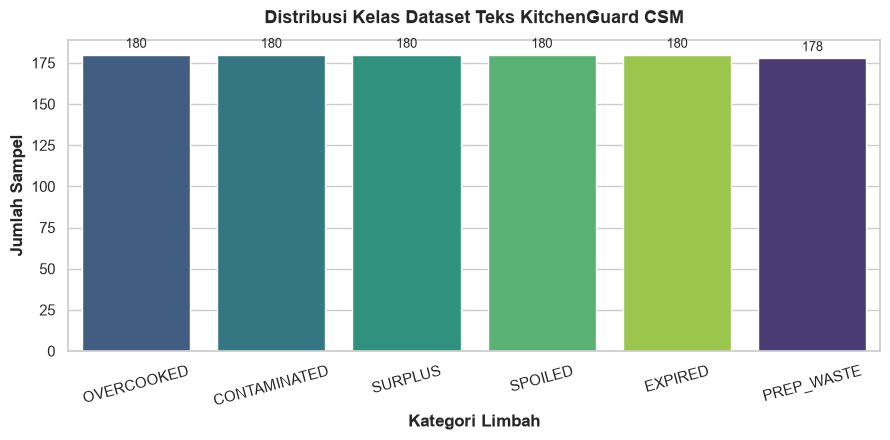

Jumlah Sampel Train (70%) : 754
Jumlah Sampel Val (15%)   : 162
Jumlah Sampel Test (15%)  : 162


In [5]:
# 1. Visualisasi Distribusi Kelas
plt.figure(figsize=(9, 4.5))
order = df_clean["category"].value_counts().index
ax = sns.countplot(data=df_clean, x="category", hue="category", order=order, palette="viridis", legend=False)
plt.title("Distribusi Kelas Dataset Teks KitchenGuard CSM", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Kategori Limbah", fontweight="bold")
plt.ylabel("Jumlah Sampel", fontweight="bold")
plt.xticks(rotation=15)
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')
plt.tight_layout()
plt.show()

# 2. Label Encoding
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(df_clean["category"].tolist())
class_names = list(label_encoder.classes_)

# 3. Stratified Train / Val / Test Split
X = np.array(df_clean["clean_text"].tolist(), dtype=object)
y = np.array(encoded_labels, dtype=int)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

val_ratio = 0.15 / (0.70 + 0.15)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=val_ratio, random_state=42, stratify=y_train_val
)

print(f"Jumlah Sampel Train (70%) : {len(X_train)}")
print(f"Jumlah Sampel Val (15%)   : {len(X_val)}")
print(f"Jumlah Sampel Test (15%)  : {len(X_test)}")

---
## Langkah 5: Representasi Teks (TF-IDF)

Mengubah teks hasil praproses menjadi angka menggunakan **TF-IDF (Term Frequency - Inverse Document Frequency)**.
- Konfigurasi `ngram_range=(1, 2)` digunakan agar model menangkap konteks unigram dan bigram (seperti: 'lewat kadaluarsa', 'jamur putih').
- Fitur di-fit **HANYA** pada Data Latih untuk mencegah *data leakage*.

In [6]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    sublinear_tf=True,
    max_features=3000,
    min_df=2
)

# Fit hanya pada train, transform pada val dan test
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Jumlah fitur n-gram (vocabulary): {len(vectorizer.vocabulary_)}")
print(f"Bentuk matriks fitur latih     : {X_train_tfidf.shape}")

Jumlah fitur n-gram (vocabulary): 1205
Bentuk matriks fitur latih     : (754, 1205)


---
## Langkah 6: Pemilihan Algoritma & Langkah 7: Pelatihan Model

Kita membandingkan 4 algoritma klasifikasi teks machine learning terkemuka:
1. **Multinomial Naive Bayes (MNB)**
2. **Support Vector Machine (Linear SVM dengan Kalibrasi Probabilitas)**
3. **Logistic Regression (Multinomial)**
4. **Random Forest Classifier**

Model dilatih pada data latih dan performanya dievaluasi pada data validasi.

Multinomial Naive Bayes   -> Val Accuracy: 100.00% | Macro F1: 1.0000
Linear SVM (Calibrated)   -> Val Accuracy: 100.00% | Macro F1: 1.0000
Logistic Regression       -> Val Accuracy: 100.00% | Macro F1: 1.0000
Random Forest             -> Val Accuracy:  99.38% | Macro F1: 0.9938


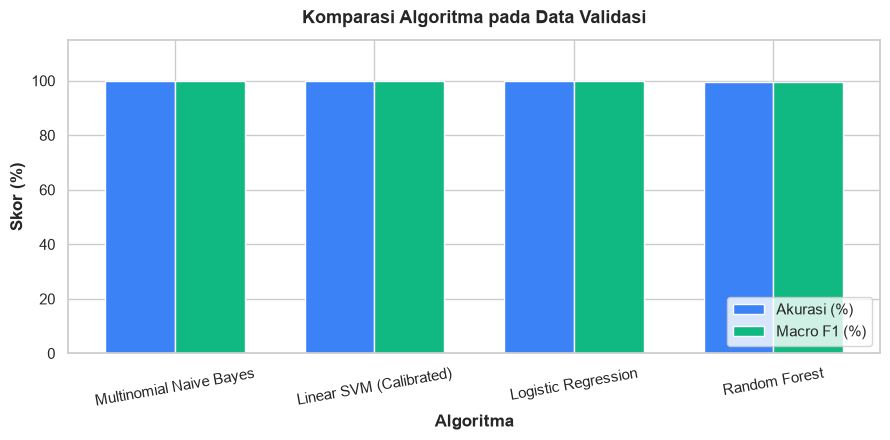


Model Terbaik Terpilih: Multinomial Naive Bayes (Macro F1: 1.0000)


In [7]:
algorithms = {
    "Multinomial Naive Bayes": MultinomialNB(alpha=0.1),
    "Linear SVM (Calibrated)": CalibratedClassifierCV(
        estimator=LinearSVC(C=1.0, random_state=42, max_iter=2000), cv=3
    ),
    "Logistic Regression": LogisticRegression(C=2.0, max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=150, max_depth=25, random_state=42)
}

val_results = {}

for name, model in algorithms.items():
    model.fit(X_train_tfidf, y_train)
    y_val_pred = model.predict(X_val_tfidf)
    
    acc = accuracy_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred, average="macro")
    val_results[name] = {"model": model, "accuracy": acc, "macro_f1": f1}
    print(f"{name:<25} -> Val Accuracy: {acc*100:6.2f}% | Macro F1: {f1:.4f}")

# Plot komparasi algoritma
plt.figure(figsize=(9, 4.5))
m_names = list(val_results.keys())
accs = [val_results[m]["accuracy"] * 100 for m in m_names]
f1s = [val_results[m]["macro_f1"] * 100 for m in m_names]
x = np.arange(len(m_names))
w = 0.35

plt.bar(x - w/2, accs, w, label="Akurasi (%)", color="#3b82f6")
plt.bar(x + w/2, f1s, w, label="Macro F1 (%)", color="#10b981")
plt.xlabel("Algoritma", fontweight="bold")
plt.ylabel("Skor (%)", fontweight="bold")
plt.title("Komparasi Algoritma pada Data Validasi", fontsize=13, fontweight="bold", pad=12)
plt.xticks(x, m_names, rotation=10)
plt.ylim(0, 115)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

best_name = max(val_results, key=lambda k: val_results[k]["macro_f1"])
best_model = val_results[best_name]["model"]
print(f"\nModel Terbaik Terpilih: {best_name} (Macro F1: {val_results[best_name]['macro_f1']:.4f})")

---
## Langkah 8: Evaluasi Model pada Data Uji (Test Set) & Decision Gate

Data uji (15% = 162 sampel) **hanya digunakan pada tahap ini** untuk memastikan hasil evaluasi objektif dan bebas bias.

Metrik yang diukur:
- Accuracy
- Precision, Recall, F1-Score (Macro & Weighted)
- Confusion Matrix Heatmap

**Decision Gate PRD KitchenGuard:**
- Target Minimum: Accuracy $\ge$ 85% dan Macro F1 $\ge$ 0.80.
- Jika ya: Lanjut ke Langkah 9 (Simpan Model).
- Jika belum: Perbaiki fitur / praproses / hyperparameter (kembali ke Langkah 3).

HASIL EVALUASI DATA UJI AKHIR (Multinomial Naive Bayes):
Accuracy  : 100.00%
Macro F1  : 1.0000

Classification Report:
              precision    recall  f1-score   support

CONTAMINATED     1.0000    1.0000    1.0000        27
     EXPIRED     1.0000    1.0000    1.0000        27
  OVERCOOKED     1.0000    1.0000    1.0000        27
  PREP_WASTE     1.0000    1.0000    1.0000        27
     SPOILED     1.0000    1.0000    1.0000        27
     SURPLUS     1.0000    1.0000    1.0000        27

    accuracy                         1.0000       162
   macro avg     1.0000    1.0000    1.0000       162
weighted avg     1.0000    1.0000    1.0000       162



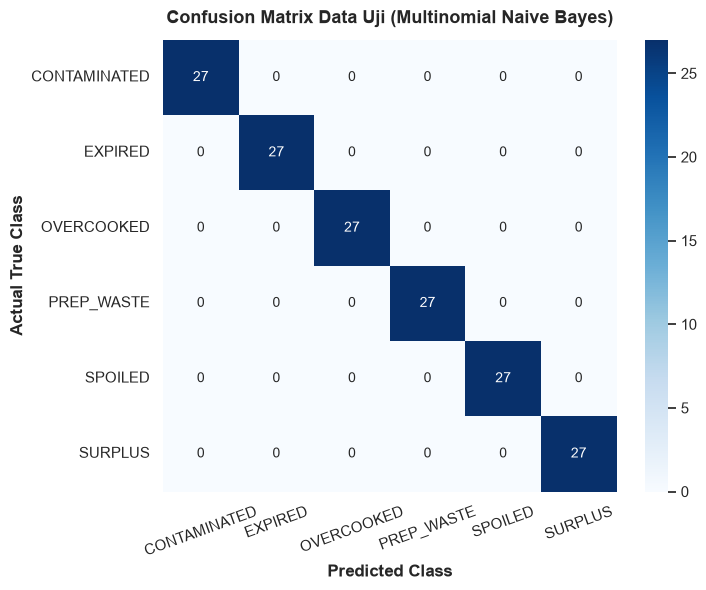


 DECISION GATE: Hasil Sudah Baik?
✓ [HASIL: YA] Performa melampaui target PRD! Lanjut ke Langkah 9.


In [8]:
# Prediksi pada Data Uji Akhir
y_test_pred = best_model.predict(X_test_tfidf)

test_acc = accuracy_score(y_test, y_test_pred)
test_f1_macro = f1_score(y_test, y_test_pred, average="macro")

print("=" * 60)
print(f"HASIL EVALUASI DATA UJI AKHIR ({best_name}):")
print(f"Accuracy  : {test_acc*100:.2f}%")
print(f"Macro F1  : {test_f1_macro:.4f}")
print("=" * 60)
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=class_names, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(7.5, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title(f"Confusion Matrix Data Uji ({best_name})", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Predicted Class", fontweight="bold")
plt.ylabel("Actual True Class", fontweight="bold")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# DECISION GATE
print("\n" + "=" * 50)
print(" DECISION GATE: Hasil Sudah Baik?")
print("=" * 50)
if test_acc >= 0.85 and test_f1_macro >= 0.80:
    print("✓ [HASIL: YA] Performa melampaui target PRD! Lanjut ke Langkah 9.")
else:
    print("✗ [HASIL: BELUM] Performa di bawah target. Kembali ke Langkah 3.")

---
## Langkah 9: Simpan Model

Menyimpan model terbaik yang sudah dilatih, objek vectorizer TF-IDF, label encoder, dan file metadata JSON ke direktori `models/` agar dapat dimuat kembali pada saat produksi tanpa perlu training ulang.

In [9]:
# Simpan artefak
models_dir = os.path.join("..", "models")
os.makedirs(models_dir, exist_ok=True)

joblib.dump(best_model, os.path.join(models_dir, "waste_classifier_model.joblib"))
joblib.dump(vectorizer, os.path.join(models_dir, "tfidf_vectorizer.joblib"))
joblib.dump(label_encoder, os.path.join(models_dir, "label_encoder.joblib"))

metadata = {
    "model_name": best_name,
    "version": "kitchenguard-text-v1.0",
    "classes": class_names,
    "test_accuracy": round(float(test_acc), 4),
    "test_macro_f1": round(float(test_f1_macro), 4)
}

with open(os.path.join(models_dir, "model_metadata.json"), "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Semua artefak model berhasil disimpan di folder 'models/'!")

Semua artefak model berhasil disimpan di folder 'models/'!


---
## Langkah 10: Implementasi & Prediksi Teks Baru

Model yang telah disimpan dimuat kembali untuk memprediksi data teks baru yang belum pernah dilihat sebelumnya secara real-time.
Sistem juga menerapkan **PRD Confidence Gate (Ambang Batas 85%)**:
- Confidence $\ge$ 85% $
ightarrow$ Status `APPROVED`, kelas prediksi dijadikan *decision-support*.
- Confidence $<$ 85% $
ightarrow$ Status `UNCERTAIN`, membutuhkan observasi manual staf dapur.

In [10]:
# Fungsi Inferensi Prediksi Teks Baru
def predict_new_kitchen_text(text, threshold=0.85):
    # 1. Praproses teks menggunakan Sastrawi
    clean = preprocess_text(text)
    
    # 2. Vektorisasi TF-IDF
    vec = vectorizer.transform([clean])
    
    # 3. Probabilitas kelas
    if hasattr(best_model, "predict_proba"):
        probs = best_model.predict_proba(vec)[0]
    else:
        probs = np.zeros(len(class_names))
        probs[best_model.predict(vec)[0]] = 1.0
        
    top_idx = int(np.argmax(probs))
    top_class = class_names[top_idx]
    confidence = float(probs[top_idx])
    
    # 4. Confidence Gate
    gate_status = "APPROVED" if confidence >= threshold else "UNCERTAIN"
    effective_class = top_class if gate_status == "APPROVED" else "UNCERTAIN"
    
    return {
        "input_text": text,
        "clean_tokens": clean,
        "predicted_class": effective_class,
        "confidence": f"{confidence*100:.2f}%",
        "gate_status": gate_status
    }

# Uji coba dengan teks baru dari dunia nyata
sample_tests = [
    "Daging sapi tenderloin berbau busuk asam dan berubah kehitaman berlendir",
    "Saus mayonnaise botol sudah lewat expired date seminggu lalu",
    "Kulit apel dan biji melon kupasan persiapan fruit salad pagi",
    "Ayam goreng gosong hangus hitam karena kompor ditinggal",
    "Ikan fillet segar jatuh ke lantai berminyak dekat tempat cuci piring",
    "Nasi tumpeng dan sup sisa buffet gathering yang tidak habis dimakan"
]

print("PENGUJIAN PREDIKSI TEKS BARU:")
print("=" * 80)
for sample in sample_tests:
    res = predict_new_kitchen_text(sample)
    print(f"Input : '{res['input_text']}'")
    print(f"Tokens: {res['clean_tokens']}")
    print(f"Hasil : [{res['predicted_class']}] (Confidence: {res['confidence']}, Gate: {res['gate_status']})")
    print("-" * 80)

PENGUJIAN PREDIKSI TEKS BARU:
Input : 'Daging sapi tenderloin berbau busuk asam dan berubah kehitaman berlendir'
Tokens: daging sapi tenderloin bau busuk asam ubah hitam lendir
Hasil : [SPOILED] (Confidence: 99.68%, Gate: APPROVED)
--------------------------------------------------------------------------------
Input : 'Saus mayonnaise botol sudah lewat expired date seminggu lalu'
Tokens: saus mayonnaise botol expired date minggu
Hasil : [EXPIRED] (Confidence: 99.97%, Gate: APPROVED)
--------------------------------------------------------------------------------
Input : 'Kulit apel dan biji melon kupasan persiapan fruit salad pagi'
Tokens: kulit apel biji melon kupas siap fruit salad pagi
Hasil : [PREP_WASTE] (Confidence: 97.50%, Gate: APPROVED)
--------------------------------------------------------------------------------
Input : 'Ayam goreng gosong hangus hitam karena kompor ditinggal'
Tokens: ayam goreng gosong hangus hitam kompor tinggal
Hasil : [OVERCOOKED] (Confidence: 99.93%,